# Style Image Analysis

Analyses every JPEG in the chosen folder and recommends `STYLE_WEIGHT` / `CONTENT_WEIGHT`
for Johnson-style neural style-transfer training (feed-forward, Gram-matrix loss).

**Metrics used**

| Metric | Meaning |
|---|---|
| `flat%` | % of 16×16 blocks that are nearly uniform (std < 10). High → geometric / flat style. |
| `p_std` | Mean local patch std-dev. High → rich texture. |
| `edge` | Mean finite-difference edge density. High → strong structural signal. |
| `l_var` | Local texture variance in 8×8 blocks — strongest predictor of training success. |

**Decision rules**

| `l_var` | `flat%` | `STYLE_WEIGHT` | `CONTENT_WEIGHT` | Expected quality |
|---|---|---|---|---|
| ≥ 900 | < 20% | 1e8 | 1e5 | ✓ Excellent |
| ≥ 700 | any | 3e8 | 1e5 | ✓ Good |
| 400–700 | < 40% | 5e8 | 5e4 | ~ Moderate |
| any | ≥ 40% | 5e8–1e9 | 5e4 | ⚠ Weak / ceiling |

In [1]:
import pathlib

# ── Edit this path to point at the folder containing your style JPEGs ────────
STYLE_DIR = pathlib.Path("../sample_images/style-pics")
# ─────────────────────────────────────────────────────────────────────────────

assert STYLE_DIR.exists(), f"Folder not found: {STYLE_DIR.resolve()}"
images = sorted(STYLE_DIR.glob("*.jpg")) + sorted(STYLE_DIR.glob("*.jpeg"))
print(f"Found {len(images)} image(s) in {STYLE_DIR.resolve()}")

Found 13 image(s) in C:\Users\i09300076\OneDrive - Endress+Hauser\DEV\Python3\style_transfer\sample_images\style-pics


In [2]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from PIL import Image


def _analyse_style_image(img_path: pathlib.Path) -> dict:
    """Return texture/geometry metrics for one style image."""
    img = Image.open(img_path).convert("RGB").resize((512, 512))
    arr = np.array(img, dtype=float)
    gray = arr.mean(axis=2)

    # Flatness: fraction of 16×16 blocks with std < 10 (uniform colour areas)
    patches16 = sliding_window_view(gray, (16, 16))[::16, ::16]
    patch_stds = patches16.std(axis=(-1, -2))
    flat_pct = float((patch_stds < 10).mean() * 100)
    mean_patch_std = float(patch_stds.mean())

    # Edge density (Sobel approximation via finite differences)
    dx = float(np.abs(np.diff(gray, axis=1)).mean())
    dy = float(np.abs(np.diff(gray, axis=0)).mean())
    edge_density = (dx + dy) / 2

    # Overall colour variability
    color_std = float(arr.std(axis=(0, 1)).mean())

    # Local texture variance (8×8 blocks)
    patches8 = sliding_window_view(gray, (8, 8))[::8, ::8]
    local_var = float(patches8.var(axis=(-1, -2)).mean())

    # Dominant colour fractions (sampled at 64×64)
    pixels = np.array(img.resize((64, 64)), dtype=float).reshape(-1, 3)
    white  = float((pixels > 200).all(axis=1).mean() * 100)
    black  = float((pixels < 50 ).all(axis=1).mean() * 100)
    pure_r = float(((pixels[:, 0] > 150) & (pixels[:, 1] < 100) & (pixels[:, 2] < 100)).mean() * 100)
    pure_g = float(((pixels[:, 1] > 150) & (pixels[:, 0] < 100) & (pixels[:, 2] < 100)).mean() * 100)
    pure_b = float(((pixels[:, 0] < 100) & (pixels[:, 1] < 100) & (pixels[:, 2] > 100)).mean() * 100)
    pure_y = float(((pixels[:, 0] > 150) & (pixels[:, 1] > 150) & (pixels[:, 2] < 100)).mean() * 100)

    return {
        "name": img_path.name,
        "flat_pct": flat_pct,
        "mean_patch_std": mean_patch_std,
        "edge_density": edge_density,
        "color_std": color_std,
        "local_var": local_var,
        "white": white, "black": black,
        "pure_r": pure_r, "pure_g": pure_g, "pure_b": pure_b, "pure_y": pure_y,
    }


def _recommend(m: dict) -> tuple[float, float, str]:
    """Return (style_weight, content_weight, verdict) for a metrics dict."""
    lv = m["local_var"]
    fp = m["flat_pct"]
    if lv >= 900 and fp < 20:
        return 1e8, 1e5, "✓ Excellent"
    if lv >= 700:
        return 3e8, 1e5, "✓ Good"
    if fp >= 40:
        sw = 1e9 if fp >= 55 else 5e8
        return sw, 5e4, "⚠ Weak / ceiling"
    return 5e8, 5e4, "~ Moderate"


results = [_analyse_style_image(p) for p in images]
print(f"Analysed {len(results)} image(s).")

Analysed 13 image(s).


In [3]:
header = (
    f"{'#':<3} {'Name':<42} {'flat%':>6} {'p_std':>6} {'edge':>5} "
    f"{'l_var':>7}  {'STYLE_WEIGHT':>12}  {'CONTENT_W':>9}  Verdict"
)
print(header)
print("─" * len(header))

for i, r in enumerate(results, 1):
    sw, cw, verdict = _recommend(r)
    print(
        f"{i:<3} {r['name']:<42} {r['flat_pct']:>6.1f} {r['mean_patch_std']:>6.1f} "
        f"{r['edge_density']:>5.1f} {r['local_var']:>7.1f}  {sw:>12.0e}  {cw:>9.0e}  {verdict}"
    )

#   Name                                        flat%  p_std  edge   l_var  STYLE_WEIGHT  CONTENT_W  Verdict
────────────────────────────────────────────────────────────────────────────────────────────────────────────
1   hundertwasser.jpg                             5.6   24.4   9.3   482.5         5e+08      5e+04  ~ Moderate
2   hundertwasser2.jpg                            1.9   37.9  10.9  1063.8         1e+08      1e+05  ✓ Excellent
3   style_abstract.jpg                           38.0   23.1   5.2   506.4         5e+08      5e+04  ~ Moderate
4   style_Banksy-cow (2).jpg                     27.1   29.2   7.9   811.1         3e+08      1e+05  ✓ Good
5   style_candy.jpg                               6.2   34.8  13.3   985.0         1e+08      1e+05  ✓ Excellent
6   style_Kandinsky1.jpg                         12.4   25.1   7.3   423.2         5e+08      5e+04  ~ Moderate
7   style_Kandinsky2.jpg                         60.2   15.4   3.8   431.5         1e+09      5e+04  ⚠ Weak / ce

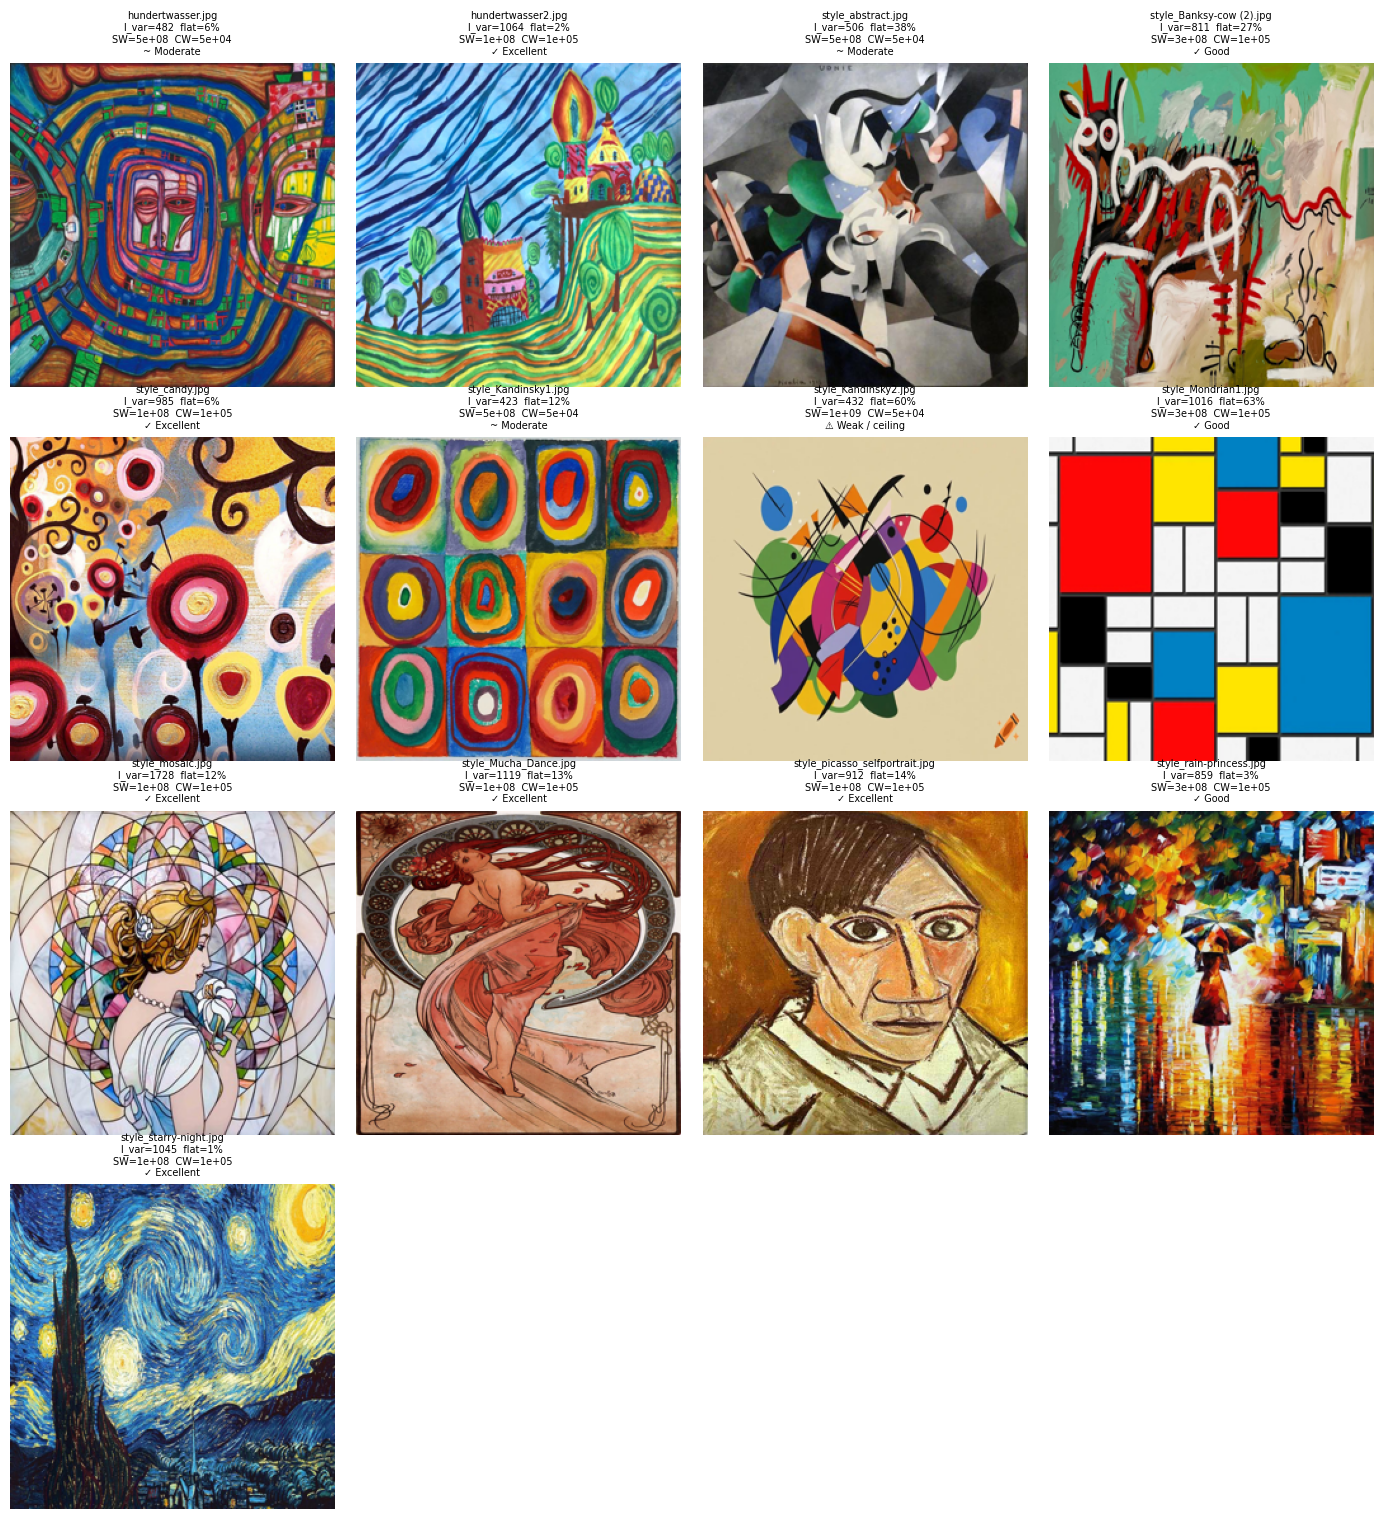

In [4]:
import math
import matplotlib.pyplot as plt

cols = 4
rows = math.ceil(len(results) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8), squeeze=False)
axes_flat = [ax for row in axes for ax in row]

for ax, r, img_path in zip(axes_flat, results, images):
    thumb = Image.open(img_path).convert("RGB").resize((256, 256))
    sw, cw, verdict = _recommend(r)
    ax.imshow(thumb)
    ax.set_title(
        f"{r['name']}\nl_var={r['local_var']:.0f}  flat={r['flat_pct']:.0f}%\n"
        f"SW={sw:.0e}  CW={cw:.0e}\n{verdict}",
        fontsize=7,
    )
    ax.axis("off")

for ax in axes_flat[len(results):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Interactive weight explorer

Pick any image from the list above. The sliders are pre-set to the recommended values.
Adjust them and read the final values at the bottom — copy-paste into Step 3 of the Kaggle training notebook.

In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output

names = [r["name"] for r in results]
rec_map = {r["name"]: (_recommend(r), r) for r in results}

img_dd = widgets.Dropdown(
    options=names,
    description="Image:",
    layout=widgets.Layout(width="440px"),
)
sw_slider = widgets.FloatLogSlider(
    value=1e8, base=10, min=7, max=10, step=0.05,
    description="STYLE_W:",
    readout_format=".1e",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="440px"),
)
cw_slider = widgets.FloatLogSlider(
    value=1e5, base=10, min=3, max=7, step=0.05,
    description="CONTENT_W:",
    readout_format=".1e",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="440px"),
)
out = widgets.Output()


def _refresh(_: object = None) -> None:
    with out:
        clear_output(wait=True)
        name = img_dd.value
        (sw_rec, cw_rec, verdict), r = rec_map[name]
        print(f"Image       : {name}")
        print(f"flat%={r['flat_pct']:.1f}  p_std={r['mean_patch_std']:.1f}  "
              f"edge={r['edge_density']:.1f}  l_var={r['local_var']:.1f}")
        print(f"Algorithm verdict : {verdict}  (rec SW={sw_rec:.0e}  CW={cw_rec:.0e})")
        print()
        print(f"─── Current selection ───────────────────────────")
        print(f"STYLE_WEIGHT   = {sw_slider.value:.2e}")
        print(f"CONTENT_WEIGHT = {cw_slider.value:.2e}")
        ratio = sw_slider.value / cw_slider.value
        print(f"Ratio S/C      = {ratio:.0f}:1  (typical 500–10,000)")


def _on_image_change(change: dict) -> None:
    (sw_rec, cw_rec, _), _ = rec_map[change["new"]]
    sw_slider.value = sw_rec
    cw_slider.value = cw_rec
    _refresh()


img_dd.observe(_on_image_change, names="value")
sw_slider.observe(_refresh, names="value")
cw_slider.observe(_refresh, names="value")

display(widgets.VBox([img_dd, sw_slider, cw_slider, out]))
_refresh()